In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import sys; sys.path.insert(0, '..')

from src.data_prep import ever_default, count_migration
from src.plot_function import plot_exclusion

warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)

In [3]:
# Import data
df = pd.read_parquet(
    '../data/raw/usedcar_transaction_score.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,APPLICATION_NUMBER,BRANCH,RESTRUCTURE_FLAG,pay_types,bal,CONTRACT_STATUS,TOTAL_TERM,OVERDUE_DAYS,CONTRACT_ID,CUSTOMER_NUMBER,...,MOB,del,avg_bal_12_to_min_bal_12,min_pay_6,avg_pay_9_to_due,max_ovd_6_to_fin,max_del_3,min_due_9_to_fin,score_from_model,score_band
0,944370,A,N,1,507120.0,10,60.0,0,944370,6626063,...,0.0,0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
1,944370,A,N,2,498668.0,10,60.0,0,944370,6626063,...,1.0,0,0.083333,0.0,0.000000,0.0,0.0,0.021251,582.0,B3
2,944370,A,N,2,490216.0,10,60.0,0,944370,6626063,...,2.0,0,0.168079,0.0,0.111111,0.0,0.0,0.021251,582.0,B3
3,944370,A,N,2,481764.0,10,60.0,0,944370,6626063,...,3.0,0,0.254310,0.0,0.222222,0.0,0.0,0.021251,582.0,B3
4,944370,A,N,2,473312.0,10,60.0,0,944370,6626063,...,4.0,0,0.342105,0.0,0.333333,0.0,0.0,0.021251,515.0,B4


In [4]:
# Constant parameters
ID_COL = 'Br_Con' #Primary key
PERIOD_COL = 'Monthkey' #Date key
DEFAULT_COL = 'del' #Default column
DEFAULT_FLAG = 4 #Any values greater than this value will be considered as default
DEFAULT_LAGS = 12 #Performance window
MAX_PERIOD = df['Monthkey'].max() #Latest observation period

# ========================================== #
# Default definition is 90+ DPD in 12 months #
# ========================================== #

# ========================================== #
# Bucket definition is Days Past Due (DPD)   #
# del = 0 --> 0     DPD                      #
# del = 1 --> 1-30  DPD                      #
# del = 2 --> 31-60 DPD                      #
# del = 3 --> 61-90 DPD                      #
# del = 4 --> 90+   DPD                      #
# ========================================== #

In [5]:
# Prepare dataset
df = ever_default(
    df = df,
    id_col = ID_COL,
    period_col = PERIOD_COL,
    default_col = DEFAULT_COL,
    default_flag = DEFAULT_FLAG,
    n_lags = DEFAULT_LAGS
)

=== Processing ===
[Sort, Forward performance windows and Ever default]


In [6]:
# Exclusion criteria
"""
Rules:
    1. Less than 12 months forward performance window
        - Default definition is 90+ DPD in 12 months meaning the last 12 months are invalid.
        - Any transactions of last 12 months are excluded from development samaple. 
    2. Last transaction
        - No probability to observed.
        - Any transactions have no next month are excluded from development samaple. 
"""

# Keep log records and exclusion
excluded_logs = [['Original', len(df), 0]] #Original transaction
excluded_steps = {
    "Last 12 months performance": "Monthkey <= @MAX_PERIOD - 12",
    "Last transaction": "del1.notnull()"
}

# Exclusion
print("=== Processing ===\n[Exclusion]")
n_steps = len(excluded_steps) #Total exclusion steps

for i, (step, criteria) in enumerate(excluded_steps.items(), start = 1):
    n_before = len(df)
    df = df.query(criteria)
    n_after = len(df)
    print(f"[✓] {step:<30}: {n_before - n_after:<6} transactions")
    excluded_logs.append([step, n_before, n_after])
    is_last = (i == n_steps)
    if is_last:
        excluded_logs.append(['Final', n_after, 0])

=== Processing ===
[Exclusion]
[✓] Last 12 months performance    : 190563 transactions
[✓] Last transaction              : 6658   transactions


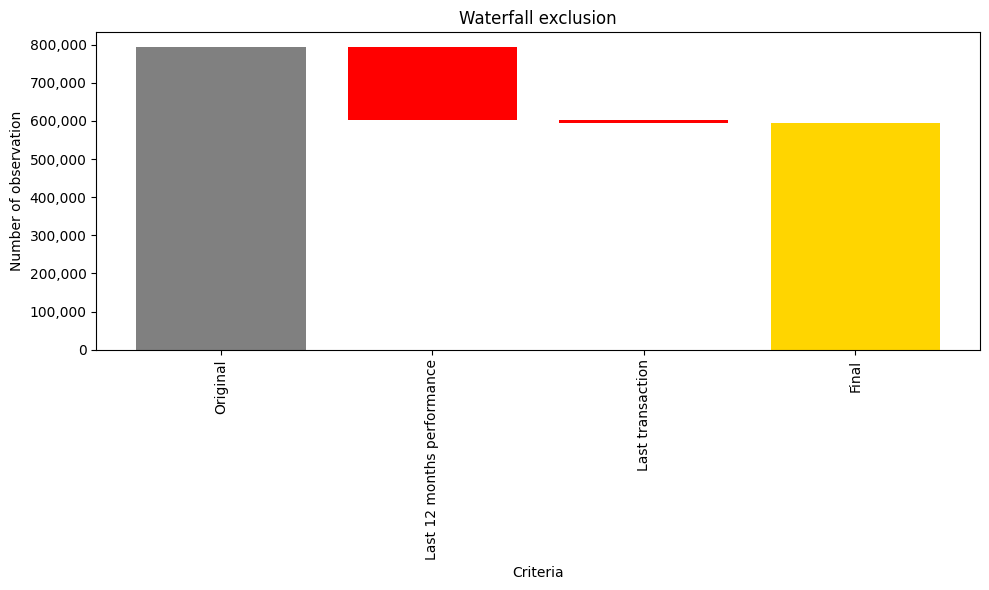

In [7]:
# Plot waterfall summary
plot_exclusion(excluded_logs)

In [8]:
# Count migration
count_migration(
    df['AS_OF_DATE'],
    df['del'],
    df['del_ever_12']
)

=== Processing ===
[Migration count]
[INFO]: Export - '..data/processed/migration_count.parquet'


In [9]:
# Export
df.to_parquet(
    '../data/processed/train_data.parquet',
    engine = 'pyarrow'
)